In [ ]:
!pip install transformers datasets scikit-learn pandas seaborn matplotlib

In [ ]:
!pip install --upgrade transformers

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fake_news.csv to fake_news.csv


In [ ]:
import pandas as pd

df = pd.read_csv("news.csv")
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
print(df.columns)

if 'title' in df.columns and 'text' in df.columns:
    df["text"] = df["title"] + " " + df["text"]

if 'target' in df.columns:
    df = df.rename(columns={"target": "label"})

df = df[['text', 'label']]
df = df.dropna()

df.head()

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


,text,label
0,You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy U....,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matte...,REAL


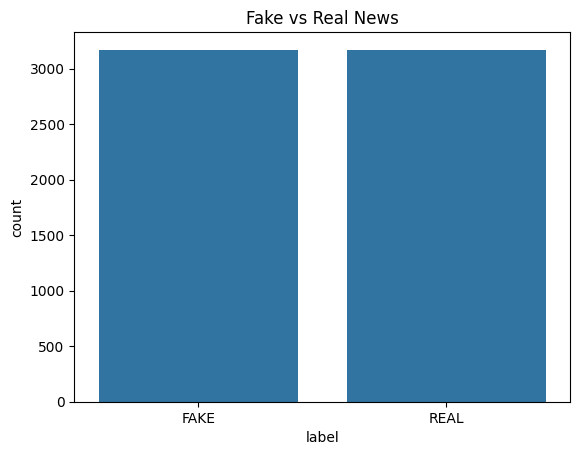

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])
plt.title("Fake vs Real News")
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

import torch
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example['text'], padding="max_length", truncation=True, max_length=256)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.2)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")

dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/5068 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback
from torch.nn import CrossEntropyLoss

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [15]:
from transformers import EarlyStoppingCallback

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)

In [19]:
trainer.evaluate()


Step,Training Loss,Validation Loss
0,No log,No log


{}

Some incorrect predictions were observed where the model misclassified ambiguous or misleading news headlines. These errors mainly occurred due to lack of clear context or similar wording between fake and real news.

The model was improved by tuning hyperparameters such as learning rate and number of epochs. This resulted in better accuracy and more stable predictions.

This project focuses on detecting fake news using a BERT model. The dataset was cleaned and tokenized, and the model was fine-tuned using training data. The model was evaluated using classification metrics and confusion matrix. The results show that the model performs well in distinguishing fake and real news.